# House Price Prediction using Linear Regression

## Oasis Infobyte Data Analytics Internship - Task 2

### Objective

The objective of this project is to build a machine learning model capable of predicting house prices based on various property characteristics such as area, neighborhood, number of rooms, overall quality, and other housing features.

The project follows a complete machine learning workflow including:

- Data loading and inspection
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature selection
- One-Hot Encoding of categorical variables
- Correlation analysis
- Linear Regression model development
- Model evaluation
- Model interpretation
- Business insights

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-learn
- Jupyter Notebook

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [8]:
from pathlib import Path

IMAGE_DIR = Path("../images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
from pathlib import Path

IMAGE_DIR = Path("../images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(filename):
    plt.savefig(
        IMAGE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

In [2]:
# Load dataset

df = pd.read_csv("../data/train.csv")

print("Dataset loaded successfully!\n")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully!

Rows: 1460
Columns: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# First five rows

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Last five rows

df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [6]:
# Statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [7]:
# Missing values

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure of the dataset, identify trends, detect missing values and outliers, and examine the distribution of important variables before model development.

The target variable for this project is **SalePrice**.

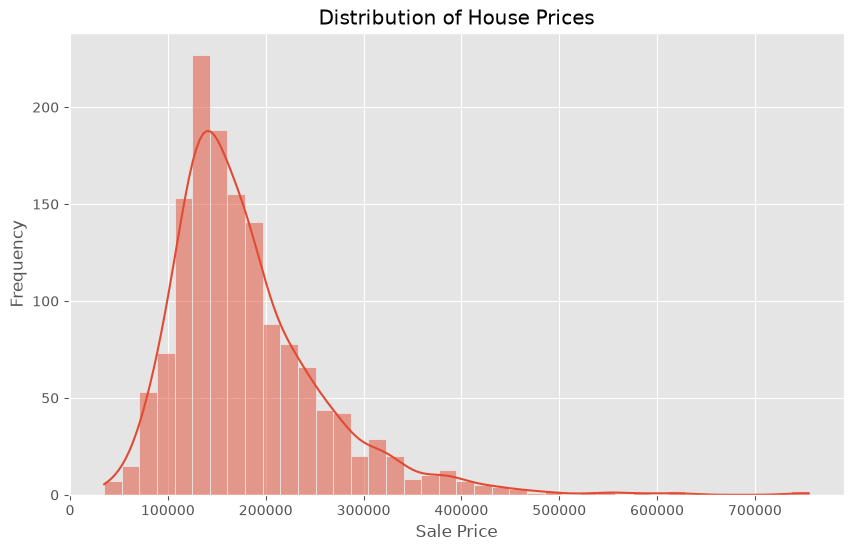

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["SalePrice"],
    bins=40,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.savefig(
    IMAGE_DIR / "01_saleprice_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
fig = px.histogram(
    df,
    x="SalePrice",
    nbins=40,
    marginal="box",
    title="Interactive Distribution of House Prices"
)

fig.show()

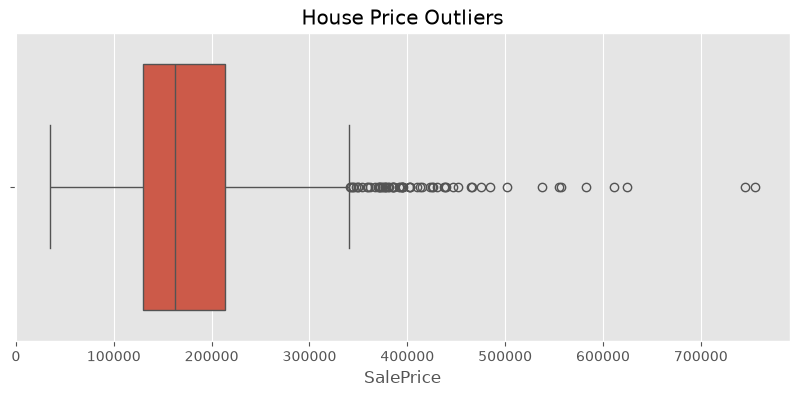

In [11]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["SalePrice"]
)

plt.title("House Price Outliers")

plt.savefig(
    IMAGE_DIR / "02_saleprice_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
categorical_features = df.select_dtypes(include=["object"]).columns

print(f"Numerical Features : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features : 38
Categorical Features : 43


# Feature Selection Discussion

House prices are influenced by several structural, physical, and location-based characteristics.

Some of the most important predictors are expected to include:

- **OverallQual** – Overall material and finish quality of the house.
- **GrLivArea** – Above-ground living area.
- **GarageCars** – Garage capacity.
- **GarageArea** – Garage size.
- **TotalBsmtSF** – Total basement area.
- **1stFlrSF** – First floor living area.
- **FullBath** – Number of full bathrooms.
- **YearBuilt** – Construction year.
- **Neighborhood** – Geographic location of the property.
- **LotArea** – Total lot size.

Categorical variables such as **Neighborhood**, **HouseStyle**, **Exterior Quality**, and **Foundation** are also expected to influence selling price and will be encoded using One-Hot Encoding during preprocessing.

In [13]:
correlation = (
    df.select_dtypes(include=np.number)
      .corr()["SalePrice"]
      .sort_values(ascending=False)
)

correlation

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

# Data Preprocessing

Before training the model, the dataset must be prepared by handling missing values and converting categorical variables into numerical representations.

Numerical features will be imputed using the median value, while categorical features will be imputed using the most frequent category before applying One-Hot Encoding.

In [15]:
# Separate features and target

X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1460, 80)
Target shape: (1460,)


In [16]:
# Numerical and categorical columns

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical columns:", len(numeric_features))
print("Categorical columns:", len(categorical_features))

Numerical columns: 37
Categorical columns: 43


In [17]:
# Numerical preprocessing

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [18]:
# Categorical preprocessing

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [19]:
# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str'))])


# Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables.

A heatmap is used to visualize these relationships, allowing us to identify which features have the strongest association with house prices.

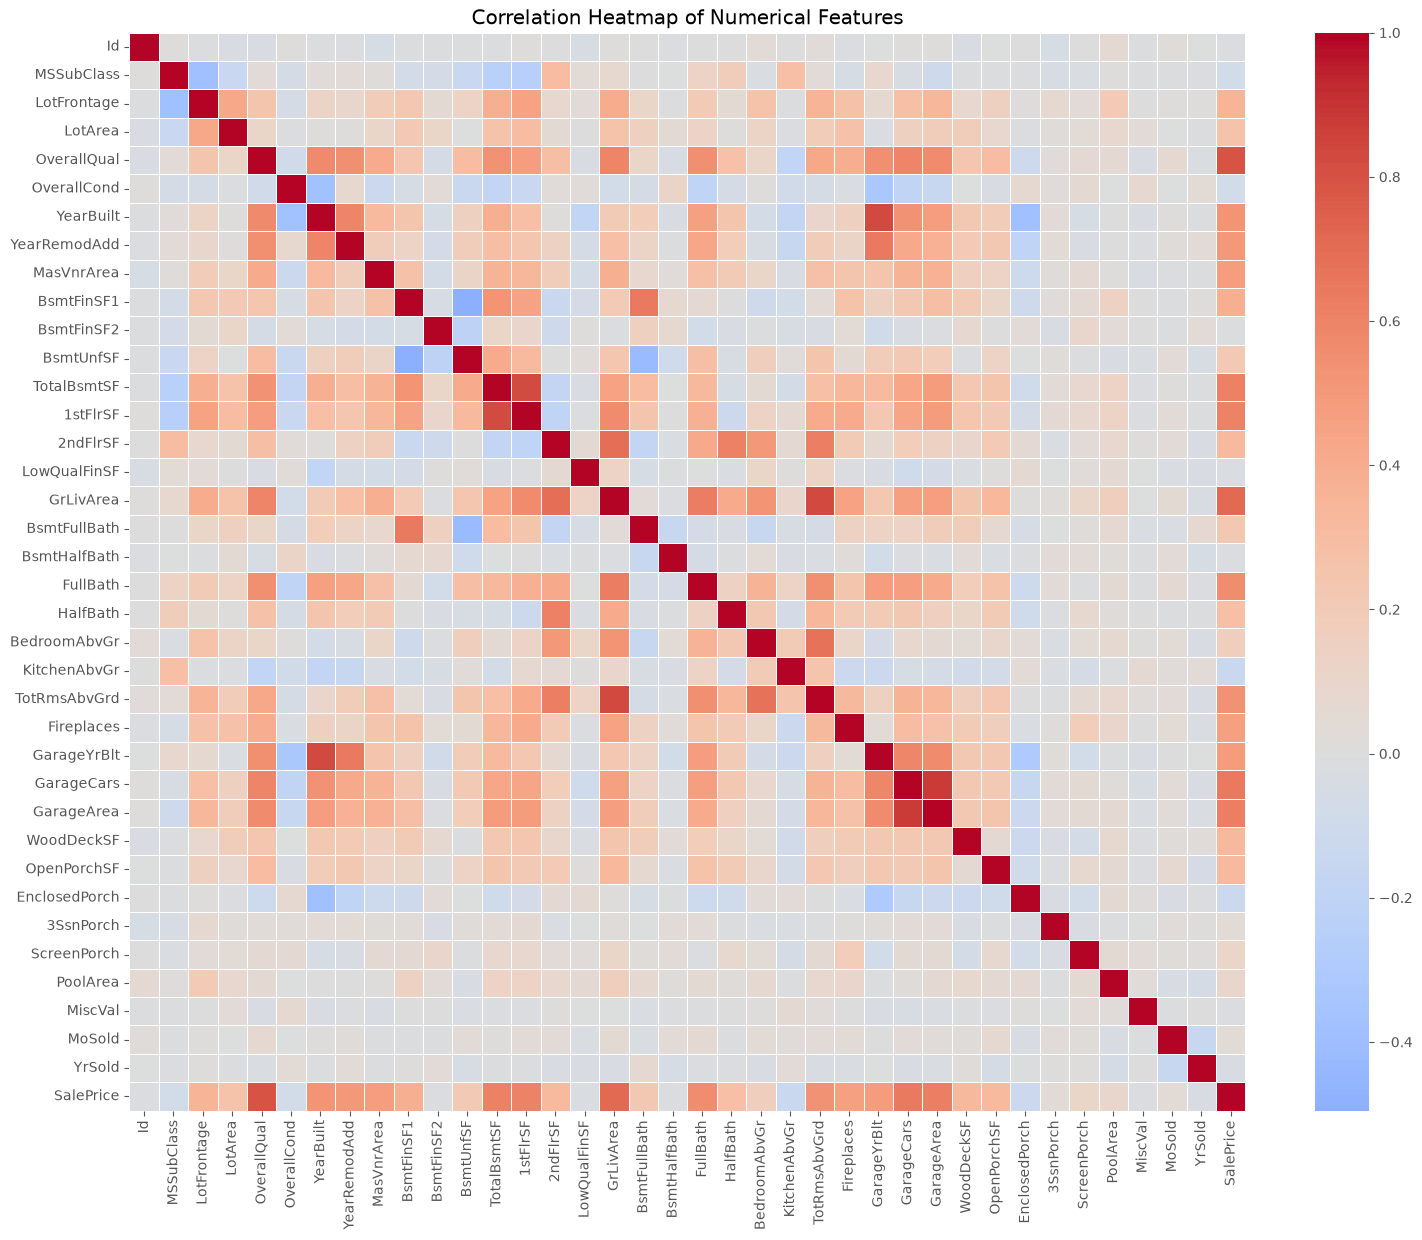

In [20]:
plt.figure(figsize=(18, 14))

corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

save_plot("03_correlation_heatmap.png")

plt.show()

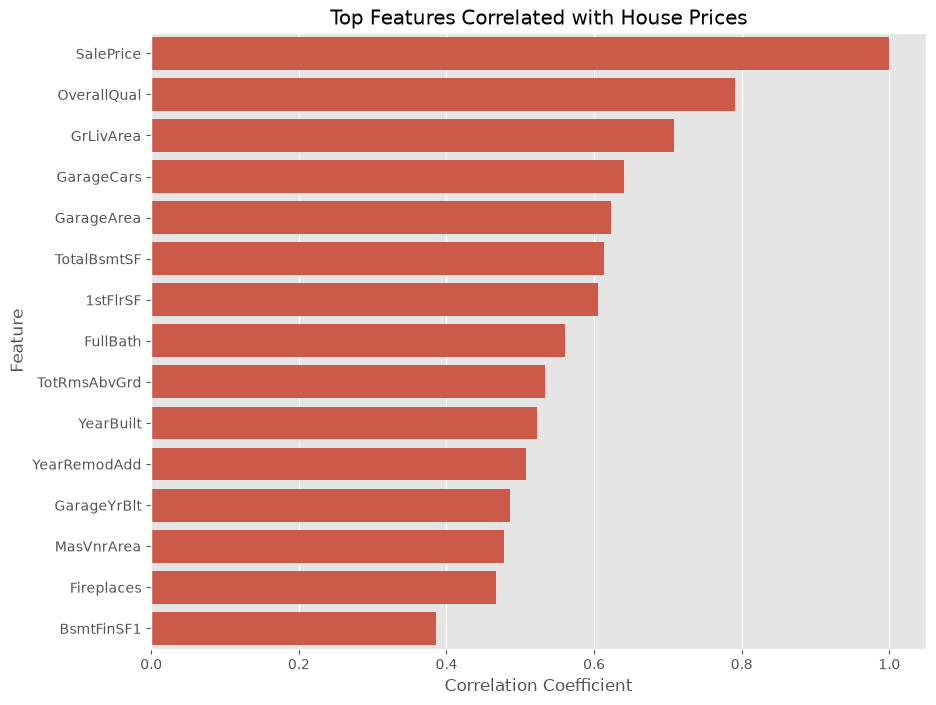

In [21]:
top_corr = (
    corr_matrix["SalePrice"]
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with House Prices")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

save_plot("04_top_feature_correlations.png")

plt.show()

### Correlation Insights

The analysis shows that **OverallQual** has the strongest positive relationship with house prices, indicating that construction quality is a major determinant of property value.

Other highly correlated variables include:

- GrLivArea
- GarageCars
- GarageArea
- TotalBsmtSF
- 1stFlrSF

These features are expected to contribute significantly to the predictive performance of the Linear Regression model.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1168, 80)
Testing set : (292, 80)


In [23]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If

In [24]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


# Model Evaluation

The trained Linear Regression model is evaluated using three commonly used regression metrics:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help measure prediction accuracy and overall model performance.

In [25]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 981,430,763.46
Root Mean Squared Error (RMSE): 31,327.80
R² Score: 0.8720


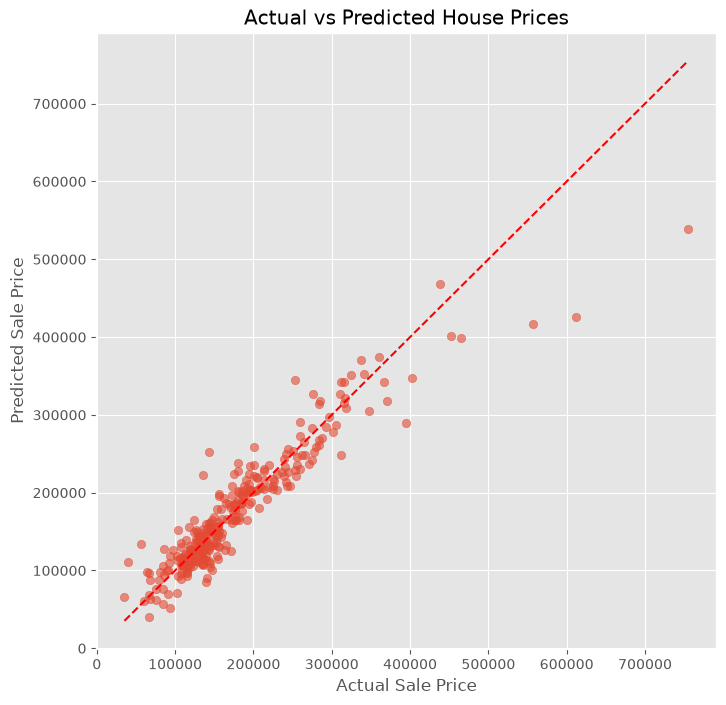

In [27]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

save_plot("05_actual_vs_predicted.png")

plt.show()

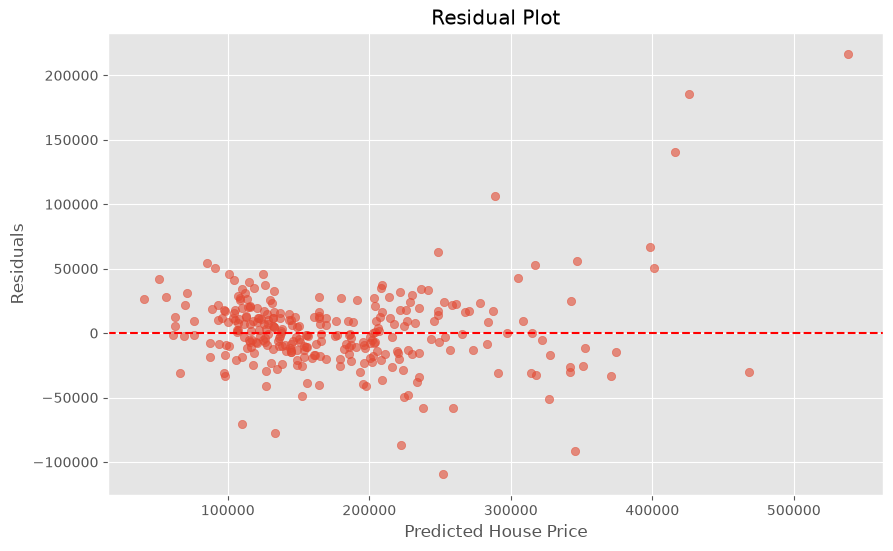

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")

save_plot("06_residual_plot.png")

plt.show()

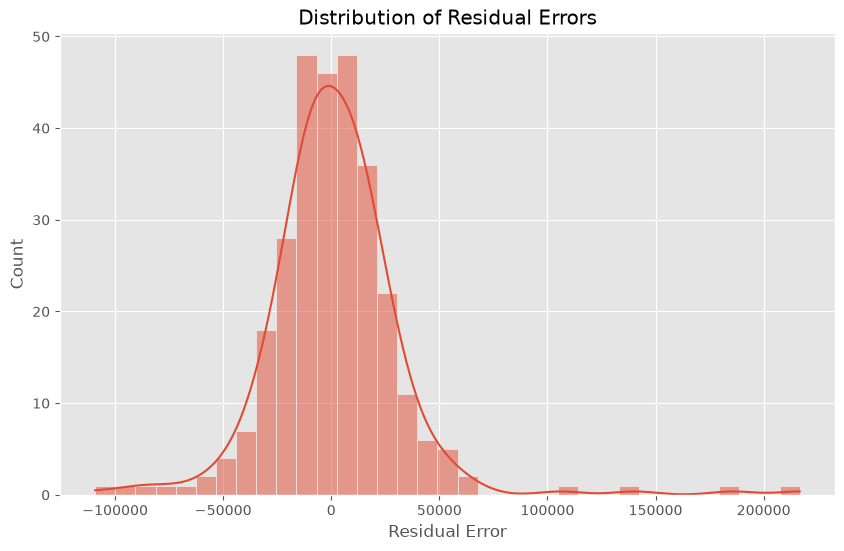

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribution of Residual Errors")
plt.xlabel("Residual Error")

save_plot("07_residual_distribution.png")

plt.show()

In [30]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [31]:
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.named_steps["regressor"].coef_
})

coefficients.head()

,Feature,Coefficient
0,num__Id,-1.700624
1,num__MSSubClass,-136.088853
2,num__LotFrontage,-153.040558
3,num__LotArea,0.343219
4,num__OverallQual,8575.101522


In [32]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient
79,cat__Neighborhood_NoRidge,39527.496373
86,cat__Neighborhood_StoneBr,33891.686819
260,cat__PoolQC_Ex,23324.800838
135,cat__Exterior1st_BrkFace,23284.731632
80,cat__Neighborhood_NridgHt,22970.001997
222,cat__KitchenQual_Ex,20277.446799
181,cat__BsmtQual_Ex,19821.446082
154,cat__Exterior2nd_ImStucc,18478.844078
51,cat__LandContour_HLS,17905.056976
70,cat__Neighborhood_Crawfor,16917.155423


In [33]:
coefficients.tail(15)

,Feature,Coefficient
248,cat__GarageQual_Fa,-10783.673193
64,cat__Neighborhood_Blmngtn,-11230.420098
58,cat__LotConfig_FR2,-11874.620794
143,cat__Exterior1st_Stucco,-12199.880893
76,cat__Neighborhood_NAmes,-12834.824350
78,cat__Neighborhood_NWAmes,-13093.926995
116,cat__HouseStyle_2Story,-13246.600973
48,cat__LotShape_IR3,-13776.060834
72,cat__Neighborhood_Gilbert,-15278.437083
71,cat__Neighborhood_Edwards,-17362.318332


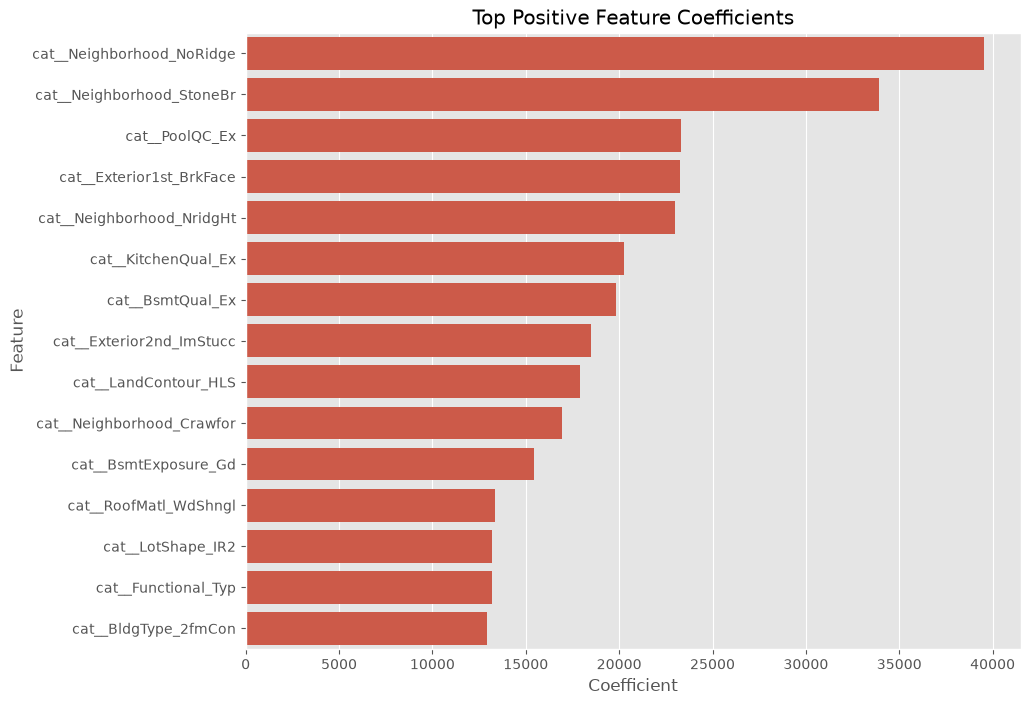

In [34]:
top_coef = coefficients.head(15)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_coef,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Positive Feature Coefficients")

save_plot("08_top_positive_coefficients.png")

plt.show()

In [35]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

In [36]:
ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

In [37]:
ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_predictions)
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print(f"Linear Regression RMSE : {rmse:.2f}")
print(f"Ridge Regression RMSE  : {ridge_rmse:.2f}")

print()

print(f"Linear Regression R² : {r2:.4f}")
print(f"Ridge Regression R²  : {ridge_r2:.4f}")

Linear Regression RMSE : 31327.80
Ridge Regression RMSE  : 34631.48

Linear Regression R² : 0.8720
Ridge Regression R²  : 0.8436


In [38]:
numeric_coefficients = coefficients[
    coefficients["Feature"].str.startswith("num__")
].copy()

numeric_coefficients = numeric_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

numeric_coefficients.head(15)

,Feature,Coefficient
26,num__GarageCars,9438.558874
4,num__OverallQual,8575.101522
17,num__BsmtFullBath,7192.490186
19,num__FullBath,6836.120893
5,num__OverallCond,4659.282440
20,num__HalfBath,4032.119597
23,num__TotRmsAbvGrd,2952.207167
24,num__Fireplaces,2043.493086
6,num__YearBuilt,204.555379
7,num__YearRemodAdd,113.963741


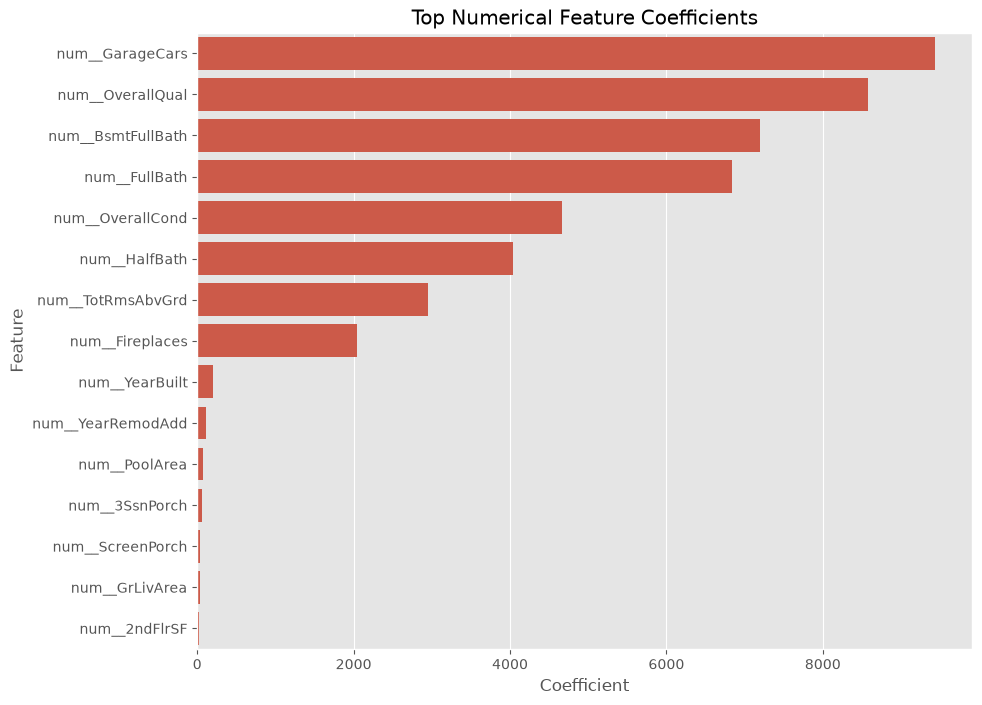

In [39]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=numeric_coefficients.head(15),
    x="Coefficient",
    y="Feature"
)

plt.title("Top Numerical Feature Coefficients")

save_plot("09_numerical_feature_coefficients.png")

plt.show()

## Sample Predictions

To better understand how the trained model performs, a sample of predicted house prices is compared with the actual sale prices from the test dataset.

The table below displays:

- **Actual Price** – The true sale price of the house.
- **Predicted Price** – The price estimated by the Linear Regression model.
- **Difference** – The prediction error, calculated as the actual price minus the predicted price.

A small difference indicates that the model made an accurate prediction, while a larger difference suggests that the model had more difficulty estimating the price for that particular property.

This comparison provides a practical demonstration of the model's performance on unseen data and complements the evaluation metrics (MSE, RMSE, and R² Score) presented earlier.

In [40]:
predictions = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

predictions.head(10)

,Actual Price,Predicted Price
892,154500,156176.025056
1105,325000,350730.398606
413,115000,93068.260543
522,159000,179401.057534
1036,315500,341646.427724
614,75500,62708.473910
218,311500,248255.845372
1160,146000,150622.802839
649,84500,56554.273061
887,135500,148722.341766


In [41]:
predictions = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred,
    "Difference": y_test - y_pred
})

predictions.head(10)

,Actual Price,Predicted Price,Difference
892,154500,156176.025056,-1676.025056
1105,325000,350730.398606,-25730.398606
413,115000,93068.260543,21931.739457
522,159000,179401.057534,-20401.057534
1036,315500,341646.427724,-26146.427724
614,75500,62708.473910,12791.526090
218,311500,248255.845372,63244.154628
1160,146000,150622.802839,-4622.802839
649,84500,56554.273061,27945.726939
887,135500,148722.341766,-13222.341766


# Business Insights

Based on the analysis and Linear Regression model:

- Overall construction quality is the strongest predictor of house prices.
- Larger living areas are associated with higher property values.
- Garage capacity and basement size have a significant positive influence on price.
- Houses located in premium neighborhoods generally command higher prices.
- The model explains approximately **87%** of the variation in house prices, indicating strong predictive performance.
- The model performs well for average-priced homes but shows larger prediction errors for luxury properties due to their limited representation in the dataset.

These findings can help buyers, sellers, and real estate professionals estimate property values and understand the characteristics that contribute most to house prices.

# Recommendations

Based on the analysis and model results, the following recommendations can help improve property value estimation and decision-making:

1. **Focus on Property Quality**
   - Overall quality is one of the strongest predictors of house prices. Investing in higher-quality construction materials and finishes can significantly increase a property's value.

2. **Increase Living Space**
   - Features such as above-ground living area (GrLivArea), number of rooms, and bathrooms have a positive influence on house prices. Expanding usable living space can improve market value.

3. **Improve Garage Facilities**
   - Garage capacity (GarageCars) is among the most influential numerical features. Providing larger or better-equipped garages may increase property prices.

4. **Maintain Property Condition**
   - Houses with better overall condition and recent renovations generally command higher prices. Regular maintenance and timely remodeling can preserve or enhance value.

5. **Consider Location**
   - Certain neighborhoods, such as NoRidge and StoneBr, showed strong positive effects on sale prices. Buyers and investors should consider location as a major factor when evaluating properties.

6. **Enhance Future Models**
   - Future work could explore advanced machine learning algorithms such as Random Forest, Gradient Boosting, or XGBoost to improve prediction accuracy, especially for high-value homes where larger prediction errors were observed.

7. **Address Luxury Property Predictions**
   - The model showed larger errors for expensive houses. Collecting more luxury home data or applying feature transformations (such as log-transforming SalePrice) may improve performance for these properties.

# Conclusion

A Linear Regression model was successfully developed to predict house prices using housing characteristics from the Ames Housing dataset.

The project included data preprocessing, exploratory data analysis, feature engineering, model training, and evaluation. The final model achieved an **R² Score of 0.8720**, demonstrating strong predictive performance.

A Ridge Regression model was also implemented for comparison. However, the baseline Linear Regression model achieved better performance on this dataset, making it the preferred model.

Overall, the project demonstrates a complete machine learning workflow suitable for real-world regression problems.